# Lab 8. Plot examples with `matplotlib`. Plot and pandas dataframe formatting and annotations.

## 1. Radar Chart

A radar chart (also known online as a polar chart, spider chart, or star chart) is a type of chart that is well-suited for comparing several characteristics across a small number of observations, typically two.

> Documentation:
> * https://matplotlib.org/stable/gallery/specialty_plots/radar_chart.html
> * library with examples: https://matplotlib.org/stable/gallery/pie_and_polar_charts/index.html

In [26]:
import numpy as np
import matplotlib.pyplot as plt

**Listing 1**

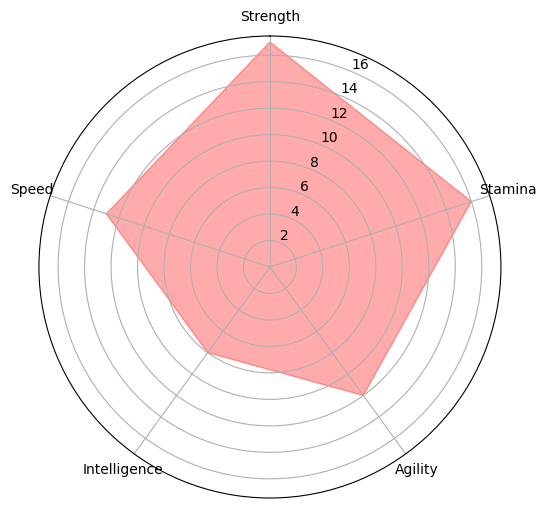

In [27]:
# radar chart example

# data
labels = ['Strength', 'Stamina', 'Agility', 'Intelligence', 'Speed']
data = [17, 16, 12, 8, 13]

# angles - number of axis on radar plot - depends on number of features (labels)
# linspace - creates linear space for a given range and number of values
# here - we divide a circle (360 degrees = 2 * np.pi) into 5 equal parts
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# now we fill pieces witj a color ang set a transparency equal to 33%
ax.fill(angles, data, color='red', alpha=0.33)
# we can draw lines at the edges of a space (optional)
# ax.plot(angles, data, color='red', linewidth=1)

# Set the axes so that they start at “12 o'clock”
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# setting labels on plot for each axis to be equal to our label names
ax.set_thetagrids(np.degrees(angles), labels);

**Listing 2**

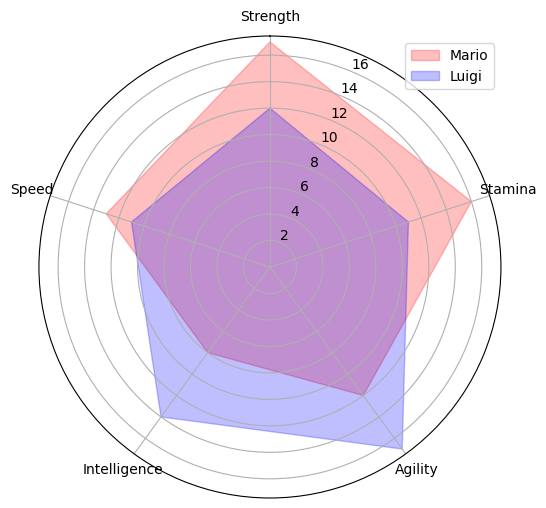

In [28]:
# example of multiple series (layers) on one plot
# data
labels = ['Strength', 'Stamina', 'Agility', 'Intelligence', 'Speed']
data = [[17, 16, 12, 8, 13], [12, 11, 17, 14, 11]]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.fill(angles, data[0], color='red', alpha=0.25, label='Mario')
ax.fill(angles, data[1], color='blue', alpha=0.25, label='Luigi')
# ax.plot(angles, data, color='red', linewidth=1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_thetagrids(np.degrees(angles), labels)
plt.legend();

## 2. Animated plots (another example)

**Listing 3**

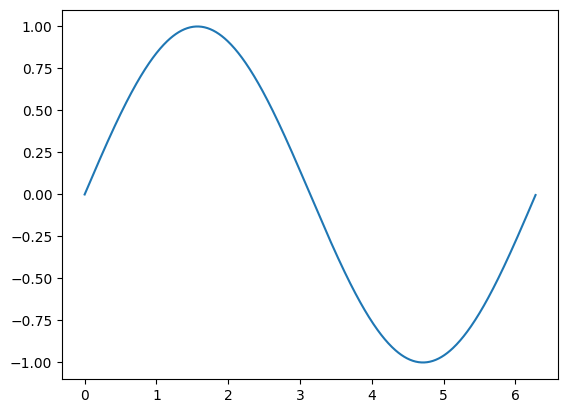

In [29]:
# Example of a chart animation from the official documentation
# https://matplotlib.org/stable/gallery/animation/simple_anim.html#sphx-glr-gallery-animation-simple-anim-py
# For the animation to work, run the script from the terminal (you can also start a terminal session via Jupyter Lab)
# the finished script is located in the test.py file

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots()

x = np.arange(0, 2*np.pi, 0.01)
line, = ax.plot(x, np.sin(x))


def animate(i):
    line.set_ydata(np.sin(x + i / 50))  # update the data.
    return line,


ani = animation.FuncAnimation(
    fig, animate, interval=20, blit=True, save_count=50)

# To save the animation, use e.g.
#
# ani.save("movie.mp4")
#
# or
#
# writer = animation.FFMpegWriter(
#     fps=15, metadata=dict(artist='Me'), bitrate=1800)
# ani.save("movie.mp4", writer=writer)

plt.show()

## 3. Plot annotations

In addition to raw data and basic information within the chart area—such as legends and axis labels—we can also “embellish” the chart with additional elements like lines, symbols, or text placed at specific locations within the chart. The placement of these elements is usually relative to values on both axes, but can also be specified as an absolute value, e.g., in the form of coordinates expressed in pixels.

**Example 1 - Vertical Line**

A vertical line at the position specified by the value on the `x` axis.
Documentation:
* https://matplotlib.org/3.10.1/api/_as_gen/matplotlib.pyplot.axline.html
* https://matplotlib.org/3.10.1/api/_as_gen/matplotlib.pyplot.axvline.html
* https://matplotlib.org/3.10.1/api/_as_gen/matplotlib.pyplot.axhline.html

**Listing 4**

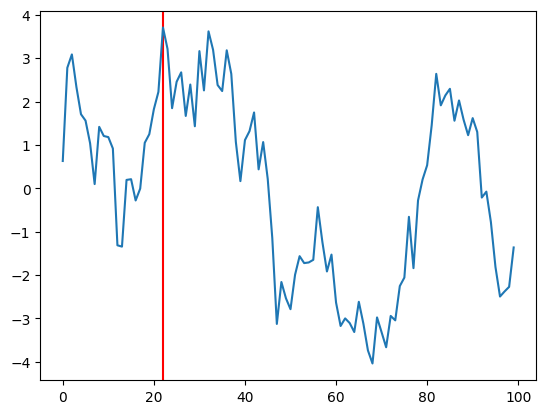

In [30]:
# data
values = np.random.randn(100).cumsum()

# vertical line on the canvas - full length
# first argument of this function is index of the data element where the line
# should be created on x axis
plt.axvline(np.argmax(values), color='r')
plt.plot(values);

**Example 2 - Graphic Objects**

These are typically symbols such as arrows, simple geometric shapes, and text.

> Documentation:
> * https://matplotlib.org/3.10.1/tutorials/text/annotations.html#sphx-glr-tutorials-text-annotations-py
> * https://matplotlib.org/stable/gallery/text_labels_and_annotations/annotation_demo.html
> * https://matplotlib.org/stable/gallery/index.html#text-labels-and-annotations

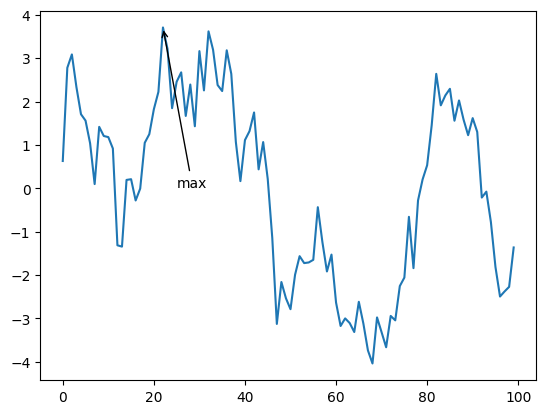

In [31]:
# We store the plot and axis objects in variables
fig, ax = plt.subplots()

# The xy parameter specifies the x1, y1 coordinates—here, the point where the arrowhead points
# The xytext parameter specifies the x2, y2 coordinates—the start of the arrow and the text position (optional)
# The xycoords and textcoords parameters indicate that the coordinates will be passed as values
# from the data (i.e., 10 represents the point with a value of 10 on the axis, not the 10th element)
ax.annotate("max",
            xy=(np.argmax(values), np.max(values)), xycoords='data',
            xytext=(len(values)/4, np.mean(values)), textcoords='data',
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="arc3"),
            );
plt.plot(values);

Rerun the code from listing 3 and 4 - the arrow is dinamically pointing to the maximum value on the plot.

**Example 3 - Filling an area**

> Documentation:
> * https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html#matplotlib.pyplot.fill_between

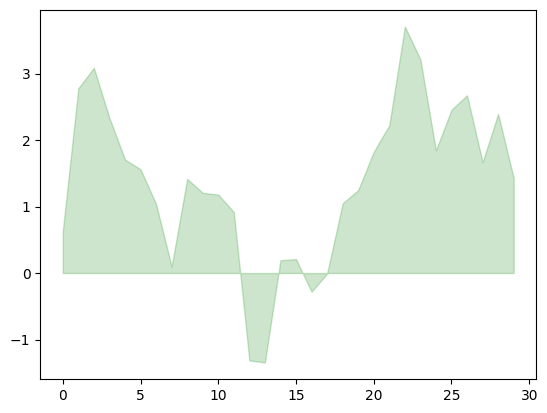

In [32]:
# x and y1 contain the coordinates that will be filled with the specified color
# both vectors must have the same number of elements
# here we retrieve the first 30 values from the entire set
plt.fill_between(
        x = list(range(30)),
        y1 = values[:30],
        color= "g",
        alpha= 0.2);

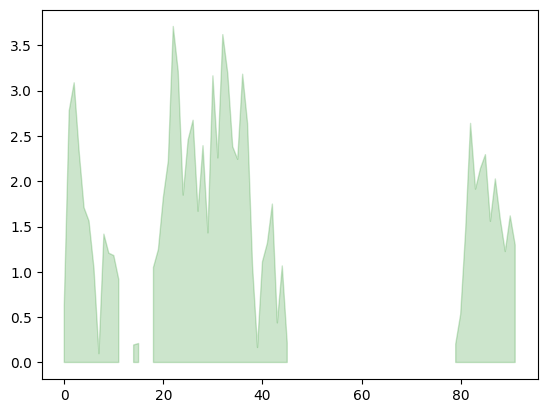

In [33]:
# Here we color the data for the entire chart, but filter it (where) to include only the values
# from the vector that meet a given condition (boolean array)
plt.fill_between(
        x = list(range(len(values))),
        y1 = values,
        where = (values > 0),
        color= "g",
        alpha= 0.2);

## 4. Formatting pandas DataFrames (in Jupyter Notebook)
In addition to being able to display a DataFrame as a clearly formatted HTML table, you can also define your own styles and formatting conditions for this output.

> Documentation:

> * https://pandas.pydata.org/docs/user_guide/style.html
> * https://www.analyticsvidhya.com/blog/2021/06/style-your-pandas-dataframe-and-make-it-stunning/
> * https://coderzcolumn.com/tutorials/python/simple-guide-to-style-display-of-pandas-dataframes

In [34]:
import pandas as pd

df = pd.read_csv('data/pkn.txt')
df['<DATE>'] = pd.to_datetime(df['<DATE>'], format='%Y%m%d')

# A minor transformation of the raw data; column names in the format <NAME> caused
# incorrect behavior with formatting-related options
df.drop(columns=['<PER>', '<TIME>', '<OPENINT>'], inplace=True)
df.columns = [column.replace('<','').replace('>','') for column in df.columns]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5583 entries, 0 to 5582
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   TICKER  5583 non-null   str           
 1   DATE    5583 non-null   datetime64[us]
 2   OPEN    5583 non-null   float64       
 3   HIGH    5583 non-null   float64       
 4   LOW     5583 non-null   float64       
 5   CLOSE   5583 non-null   float64       
 6   VOL     5583 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 321.8 KB


In [35]:
# for this example we will select only a small piece of data
df10 = df[:10]
df10.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   TICKER  10 non-null     str           
 1   DATE    10 non-null     datetime64[us]
 2   OPEN    10 non-null     float64       
 3   HIGH    10 non-null     float64       
 4   LOW     10 non-null     float64       
 5   CLOSE   10 non-null     float64       
 6   VOL     10 non-null     int64         
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 722.0 bytes


In [36]:
df10

,TICKER,DATE,OPEN,HIGH,LOW,CLOSE,VOL
0,PKN,1999-11-26,15.268,15.403,14.715,15.194,15857000
1,PKN,1999-11-29,15.124,15.194,14.852,14.923,5499196
2,PKN,1999-11-30,15.060,15.330,15.060,15.194,3287087
3,PKN,1999-12-01,15.330,15.674,15.194,15.674,3077747
4,PKN,1999-12-02,15.818,16.297,15.745,15.954,3304014
5,PKN,1999-12-03,15.954,16.225,15.818,16.159,2357914
6,PKN,1999-12-06,16.297,16.847,16.297,16.776,3005048
7,PKN,1999-12-07,16.711,16.776,16.503,16.503,2426246
8,PKN,1999-12-08,16.503,16.911,16.503,16.639,3807338
9,PKN,1999-12-09,16.639,16.639,16.225,16.503,2513405


**Example 1** - formatting output numbers.

In [37]:
# Example of formatting displayed values (output only)
df10.style.format(precision=2
                  ,thousands=" "
                  ,formatter={'OPEN': lambda x: f"{x:,.2f} zł"})

AttributeError: The '.style' accessor requires jinja2

**Example 2** - conditional formatting.

In [ ]:
# Formatting maximum values in columns + previous format
# first parameter of the highlight_max function is a subset of column names to format
df10.style.highlight_max(df10.columns[1:], color='green') \
    .format(precision=2
                  ,thousands=" "
                  ,formatter={'OPEN': lambda x: f"{x:,.2f} zł"})

,TICKER,DATE,OPEN,HIGH,LOW,CLOSE,VOL
0,PKN,1999-11-26 00:00:00,15.27 zł,15.40,14.71,15.19,15 857 000
1,PKN,1999-11-29 00:00:00,15.12 zł,15.19,14.85,14.92,5 499 196
2,PKN,1999-11-30 00:00:00,15.06 zł,15.33,15.06,15.19,3 287 087
3,PKN,1999-12-01 00:00:00,15.33 zł,15.67,15.19,15.67,3 077 747
4,PKN,1999-12-02 00:00:00,15.82 zł,16.30,15.74,15.95,3 304 014
5,PKN,1999-12-03 00:00:00,15.95 zł,16.23,15.82,16.16,2 357 914
6,PKN,1999-12-06 00:00:00,16.30 zł,16.85,16.30,16.78,3 005 048
7,PKN,1999-12-07 00:00:00,16.71 zł,16.78,16.50,16.50,2 426 246
8,PKN,1999-12-08 00:00:00,16.50 zł,16.91,16.50,16.64,3 807 338
9,PKN,1999-12-09 00:00:00,16.64 zł,16.64,16.23,16.50,2 513 405


**Example 3** - setting subsets for both formatters

In [ ]:
# We probably aren't interested in the maximum values in the column containing the asset name and date
# We can specify which columns (or, more precisely, a subset of them) should be formatted
# more on using the format() function: https://pandas.pydata.org/docs/reference/api/pandas.io.formats.style.Styler.format.html
slice_ = ['OPEN','CLOSE','LOW','HIGH','VOL']
df10.style.highlight_max(color='green', subset=slice_) \
    .format(precision=2
                  ,thousands=" "
                  ,formatter=lambda x: f"{x:,.2f} zł"
                  ,subset=['OPEN','CLOSE','LOW','HIGH'])

,TICKER,DATE,OPEN,HIGH,LOW,CLOSE,VOL
0,PKN,1999-11-26 00:00:00,15.27 zł,15.40 zł,14.71 zł,15.19 zł,15857000
1,PKN,1999-11-29 00:00:00,15.12 zł,15.19 zł,14.85 zł,14.92 zł,5499196
2,PKN,1999-11-30 00:00:00,15.06 zł,15.33 zł,15.06 zł,15.19 zł,3287087
3,PKN,1999-12-01 00:00:00,15.33 zł,15.67 zł,15.19 zł,15.67 zł,3077747
4,PKN,1999-12-02 00:00:00,15.82 zł,16.30 zł,15.74 zł,15.95 zł,3304014
5,PKN,1999-12-03 00:00:00,15.95 zł,16.23 zł,15.82 zł,16.16 zł,2357914
6,PKN,1999-12-06 00:00:00,16.30 zł,16.85 zł,16.30 zł,16.78 zł,3005048
7,PKN,1999-12-07 00:00:00,16.71 zł,16.78 zł,16.50 zł,16.50 zł,2426246
8,PKN,1999-12-08 00:00:00,16.50 zł,16.91 zł,16.50 zł,16.64 zł,3807338
9,PKN,1999-12-09 00:00:00,16.64 zł,16.64 zł,16.23 zł,16.50 zł,2513405


In [ ]:
# You can find a list of all available color maps in the matplotlib library here
# List of color maps: https://matplotlib.org/stable/users/explain/colors/colormaps.html
from matplotlib import colormaps
print(list(colormaps))

# Here's an example (like in Excel) of how to use one of them
df10.style.background_gradient(cmap='coolwarm')

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

,TICKER,DATE,OPEN,HIGH,LOW,CLOSE,VOL
0,PKN,1999-11-26 00:00:00,15.268000,15.403000,14.715000,15.194000,15857000
1,PKN,1999-11-29 00:00:00,15.124000,15.194000,14.852000,14.923000,5499196
2,PKN,1999-11-30 00:00:00,15.060000,15.330000,15.060000,15.194000,3287087
3,PKN,1999-12-01 00:00:00,15.330000,15.674000,15.194000,15.674000,3077747
4,PKN,1999-12-02 00:00:00,15.818000,16.297000,15.745000,15.954000,3304014
5,PKN,1999-12-03 00:00:00,15.954000,16.225000,15.818000,16.159000,2357914
6,PKN,1999-12-06 00:00:00,16.297000,16.847000,16.297000,16.776000,3005048
7,PKN,1999-12-07 00:00:00,16.711000,16.776000,16.503000,16.503000,2426246
8,PKN,1999-12-08 00:00:00,16.503000,16.911000,16.503000,16.639000,3807338
9,PKN,1999-12-09 00:00:00,16.639000,16.639000,16.225000,16.503000,2513405


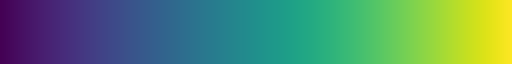

In [ ]:
# we can visualize a given color palette in Jupyter Notebook
colors = plt.colormaps['viridis']
colors

In [ ]:
# a single color is an array of normalized pixel color values (pixel_color_value / 255) for all three
# components of a RGB palette
print(colors.colors[0])

# number of all colors
len(colors.colors)

[0.267004, 0.004874, 0.329415]


256

## Tasks

**Task 1**

Based on the radar chart examples above, write a function that can display a similar chart for the data from the FIFA22_official_data.csv dataset (located in the **data** subfolder). Requirements:

* The function takes a pandas DataFrame as a vector, where the first column is the player’s name and the subsequent columns are any subset of that player’s football attributes (from Crossing to GKReflexes),
* The function and the chart should work for a variable number of attributes and for a variable number of players,
* Set a fixed range of attribute values between [0, 100],
* The axis labels on the chart are the column labels excluding the player’s name,
* Each player is represented by a different color,
* The legend also includes the player’s name.


**Task 2**

Using the [pkn.txt](./data/pkn.txt) dataset, write a script that displays an animated chart showing the closing price (the `CLOSE` column) of this security. The y-axis should show the price, and the x-axis should show the time at which each price was recorded. When the chart is first displayed, retrieve the first 20 values, and then aggregate the next reading with each animation frame. If possible, set the chart parameters so that the chart line does not lie directly at the top or right edge of the canvas.
Also update the dates of the security’s value readings on the x-axis as the animation progresses.

**Task 3**

Using the data in [pkn.txt](./data/pkn.txt), plot a line chart for the closing price and add indicators to the chart as shown in the example with annotations (Example 2), which will indicate the minimum and maximum values.

**Task 4**

Using the data from [pkn.txt](./data/pkn.txt), group the data by year and month, find the minimum and maximum values for the `CLOSE` column, and then, using the data formatting example from point 4, highlight the minimum and maximum values in this column with different styles (using the `highlight_min` and `highlight_max` functions, respectively).

In [ ]:
from IPython.display import HTML

import matplotlib.dates as mdates

# Task 1: radar chart function for FIFA22 player attributes
fifa = pd.read_csv('data/FIFA22_official_data.csv')

def plot_fifa_radar(df, title=None):
    labels = list(df.columns[1:])
    if len(labels) == 0:
        raise ValueError("DataFrame must contain at least one attribute column besides player name.")
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_ylim(0, 100)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)

    cmap = plt.get_cmap('tab10')
    for i, (_, row) in enumerate(df.iterrows()):
        values = row.iloc[1:].astype(float).tolist()
        values += values[:1]
        color = cmap(i % cmap.N)
        ax.plot(angles, values, color=color, linewidth=2, label=row.iloc[0])
        ax.fill(angles, values, color=color, alpha=0.25)

    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    if title:
        ax.set_title(title)
    plt.show()

price_range = df['CLOSE'].max() - df['CLOSE'].min()
ax.annotate(
    "min",
    xy=(min_date, min_price),
    xytext=(min_date, min_price - price_range * 0.1),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3"),
    ha='center'
)
ax.annotate(
    "max",
    xy=(max_date, max_price),
    xytext=(max_date, max_price + price_range * 0.1),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3"),
    ha='center'
)

ax.set_title("pkn closing price with min/max annotations")
ax.set_xlabel("Date")
ax.set_ylabel("CLOSE")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.show()

# Task 4: group by year and month, find min/max CLOSE and style the result
monthly_close = (
    df.groupby(
        [df['DATE'].dt.year.rename('Year'), df['DATE'].dt.month.rename('Month')]
    )['CLOSE']
    .agg(MIN='min', MAX='max')
    .reset_index()
)

monthly_close.style \
    .highlight_min(subset=['MIN'], color='lightgreen') \
    .highlight_max(subset=['MAX'], color='salmon') \
    .format({'MIN': '{:.2f}', 'MAX': '{:.2f}'})

Exemplary plot for task 1 could look like this:

![radar_plot_ex1.png](radar_plot_ex1.png)